# Traitement d'images : filtrage, seuillage, et comptage d'objets avec opencv

Une initiation à la biblithèque opencv 

# Veille technologique: Opencv python

-  Suivre les instructions et faire une recherche selon ce qui est demandé.

## Operations Simples

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\2737861700.py:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image)


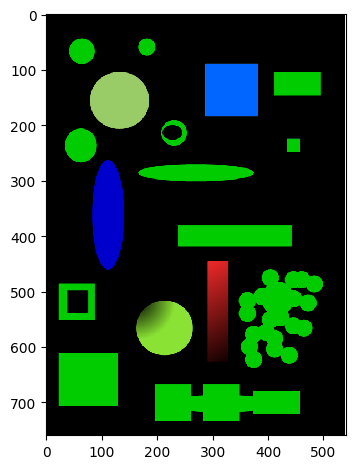

In [1]:
# use opencv to load and display the image
import cv2 #pip install opencv-python
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk #pip install scikit-image
from skimage.io import imread, imshow, imsave

# lire l'image (avec imread)
image = imread('image_01.png')
# afficher image
imshow(image)

In [2]:
# afficher la taille de l'image
image=image.shape #(longueur, largeur, nombre de canaux)
image

(760, 541, 4)

In [3]:
# l'image a trois couleur R,G,B. afficher les valeurs des trois couleurs pour le pixel x = 150, et y = 100
from PIL import Image
image = Image.open('image_01.png')

x=150
y=100
pixel=image.getpixel((x, y)) # (R,G,B)

print("R:", pixel[0])
print("G:", pixel[1])
print("B:", pixel[2])

"""getpixel() est méthode pour accéder à un pixel de corrdonées 
putpixel() est méthode pour modifier un pixel de coordonnées"""

R: 0
G: 0
B: 0


'getpixel() est méthode pour accéder à un pixel de corrdonées \nputpixel() est méthode pour modifier un pixel de coordonnées'

In [4]:
# Crop une partie de l'image (sélectionner une petite partie à partir des coordonnées)
cropped = image.crop((50, 50, 200, 200)) # (droite, haut, gauche, bas)
cropped.show() # cropper c'st à dire sélectionner une partie de l'image en spécifiant les coordonnées du rectangle à découper.


In [5]:
# redimensioner l'image à 200x200 pixels
resized = image.resize((200,200)) #resized =redimmensionner l'image à 200x200 pixels
# afficher resized
resized.show()
# qu'est ce que vous remarquez !!
"""on a remarqué que l'image est déformée,  il est étirée pour s'adapter à la nouvelle taille."""

"on a remarqué que l'image est déformée,  il est étirée pour s'adapter à la nouvelle taille."

In [6]:
# redimensinner sans affecter l'image
resized = image.resize((200,200), Image.LANCZOS) #redimensionner l'image à 200x200 pixels sans affecter la qualité de l'image
resized.show()

In [7]:
#pour regarder les deux images cote à cote pour faire la comparaison
resized1 = image.resize((50, 50))  # sans filtre
resized2 = image.resize((50, 50), Image.LANCZOS)

resized1.show()
resized2.show()
"""les différents filtres de redimmensionnement:
- Image.NEAREST : le plus rapide, mais de mauvaise qualité (pixelisation)
- Image.BILINEAR : une interpolation bilinéaire, meilleure qualité que NEAREST
- Image.BICUBIC : une interpolation bicubique, meilleure qualité que BILINEAR
- Image.LANCZOS : une interpolation de haute qualité, mais plus lente que les autres filtres
- Image.BOX : une interpolation de type boîte, qui est rapide et de bonne qualité pour les images avec des détails fins
"""

'les différents filtres de redimmensionnement:\n- Image.NEAREST : le plus rapide, mais de mauvaise qualité (pixelisation)\n- Image.BILINEAR : une interpolation bilinéaire, meilleure qualité que NEAREST\n- Image.BICUBIC : une interpolation bicubique, meilleure qualité que BILINEAR\n- Image.LANCZOS : une interpolation de haute qualité, mais plus lente que les autres filtres\n- Image.BOX : une interpolation de type boîte, qui est rapide et de bonne qualité pour les images avec des détails fins\n'

In [8]:
# faire tourner une image -45°
rotated = image.rotate(-45) # faire tourner une image de -45 degrés dans le sens des aiguilles d'une montre
rotated.show()

Vous pouvez utiliser la bibliothèque imutils pour faire les rotations et d'autres fonctions facilement. Pour l'instaler: pip install imutils

# Dessiner sur l'image

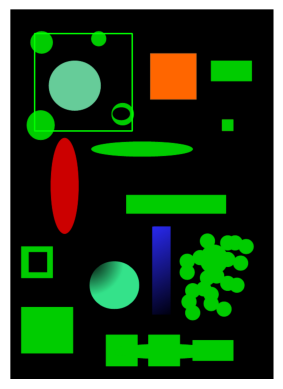

In [9]:
# dessiner un rectangle
image = Image.open("image_01.png")

# Convertir en numpy array (format OpenCV)
image = np.array(image)
dessiner_rectangle=cv2.rectangle(image,(50,50),(250,250),(0,255,0),2)
image_rgb=cv2.cvtColor(dessiner_rectangle, cv2.COLOR_RGB2BGR)
plt.imshow(image_rgb)
plt.axis('off')  # optionnel : enlève les axes
plt.show()

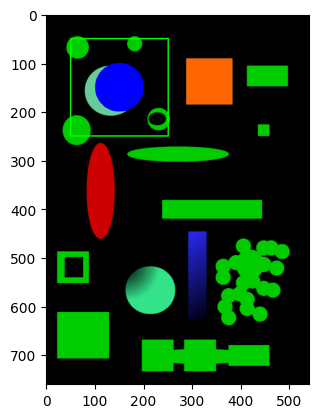

In [10]:
# dessiner un circle
image=cv2.circle(image_rgb,(150 ,150),50,(0,0,255),-1)
plt.imshow(image)
# plt.axis('off')
plt.show()

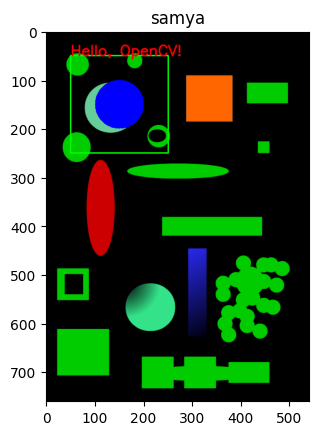

In [11]:
#AJOUTER UN TEXTE
font=cv2.FONT_HERSHEY_SIMPLEX
image=cv2.putText(image,'Hello, OpenCV!',(50,50),font,1,(255,0,0),2,cv2.LINE_AA)
plt.imshow(image)
plt.title("samya")
plt.show()


# Filtrage d'image

* Blur
* Gaussian blur
* Median blur
* Sharpening
* Bilateral blur
* Bilateral filtering

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\2640932365.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image_bois)


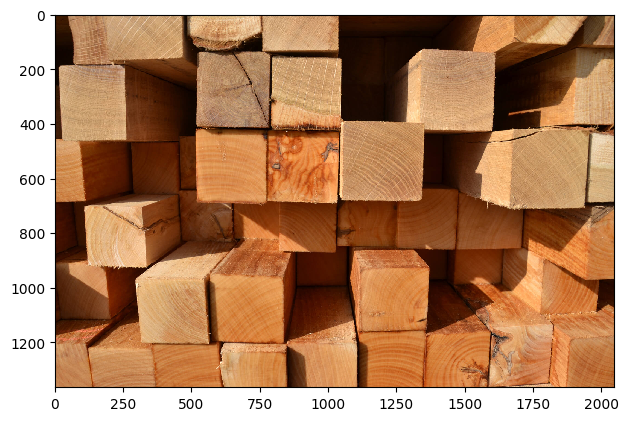

In [12]:
# charger et afficher l'image "bois"
image_bois = imread("bois.png")
imshow(image_bois)

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\1524760587.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(filtered_image)


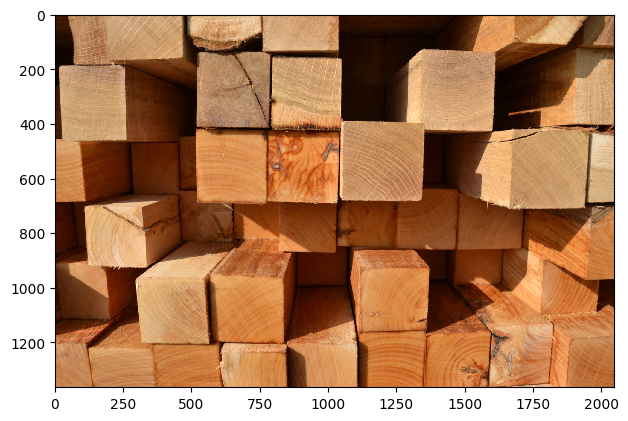

In [13]:
# Utiliser la méthode "cv2.filter2D" avec un kernel de taille 2
kernel = np.ones((2, 2), np.float32) / 4
filtered_image = cv2.filter2D(image_bois, -1, kernel)
imshow(filtered_image)


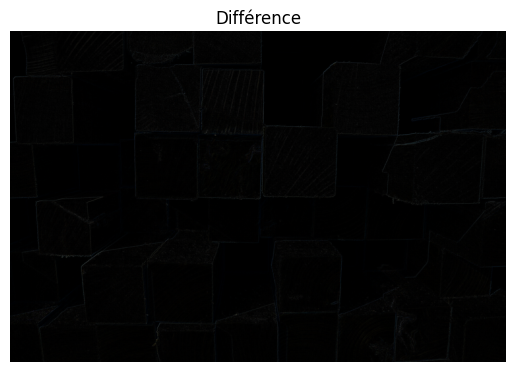

In [14]:
difference = cv2.absdiff(image_bois, filtered_image)

plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
plt.title("Différence")
plt.axis('off')
plt.show()

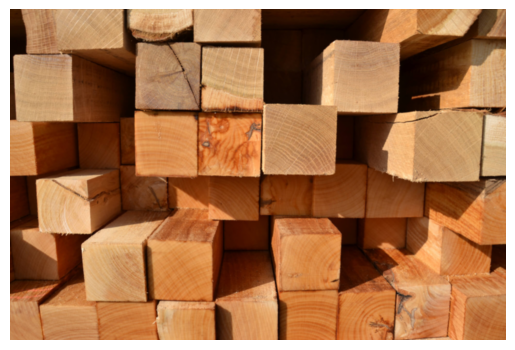

In [15]:
# Appliquer blur avec un kernel de taille 5x5
blur=cv2.blur(image_bois, (5,5))
plt.imshow(blur)
plt.axis('off')
plt.show()

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\4211576832.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(blurred_image)


'GaussianBlur est une technique pour reduire le bruit dans une image en appliquant une convolution avec un noyau gaussien.'

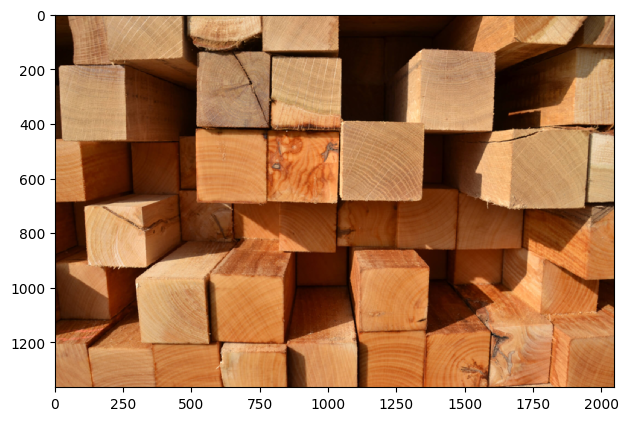

In [16]:
# gaussian blur

blurred_image = cv2.GaussianBlur(image_bois, (5, 5), cv2.BORDER_DEFAULT)
imshow(blurred_image)
"""GaussianBlur est une technique pour reduire le bruit dans une image en appliquant une convolution avec un noyau gaussien."""

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\1954181253.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(median_blurred)


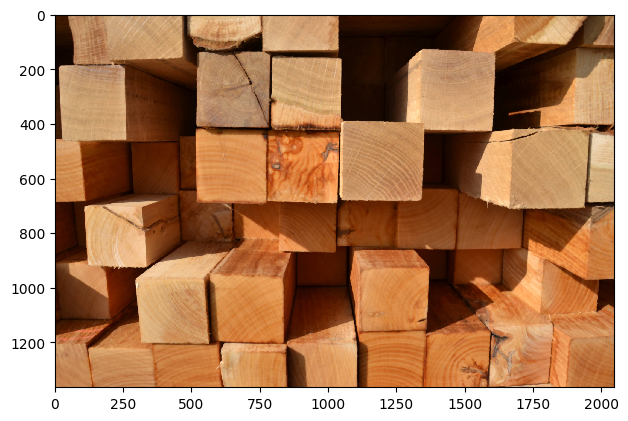

In [17]:
# median blur
median_blurred = cv2.medianBlur(image_bois, 5)
imshow(median_blurred)

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\4084221299.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(sharpened_image)


"amplifier la différence entre l'intensité d'un pixel"

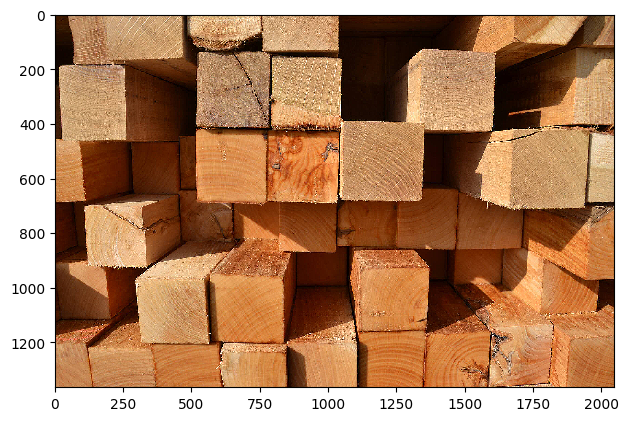

In [18]:
# sharpening
sharpening_kernel = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])
sharpened_image = cv2.filter2D(image_bois, -1, sharpening_kernel)
imshow(sharpened_image)
"""amplifier la différence entre l'intensité d'un pixel"""

C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_14944\2676771153.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow((bilateral_filtered))


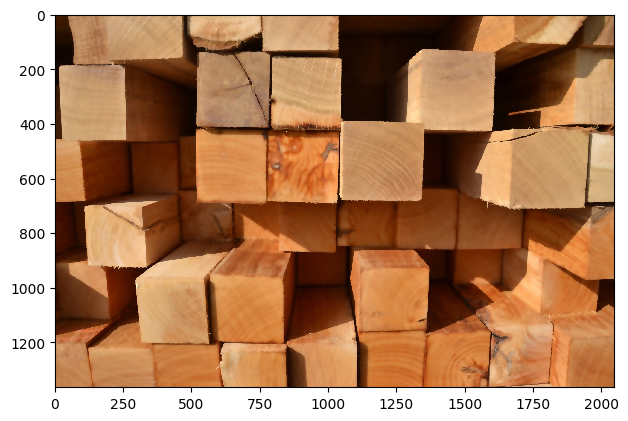

In [19]:
# bilateral filtering
bilateral_filtered=cv2.bilateralFilter(image_bois,15,75,75)
imshow((bilateral_filtered))

# Seuillage d'image

En utilisant l'image "sudoku" appliquer:
* Binary Thresholding
* Otsu thresholding
* Adaptive thresholding

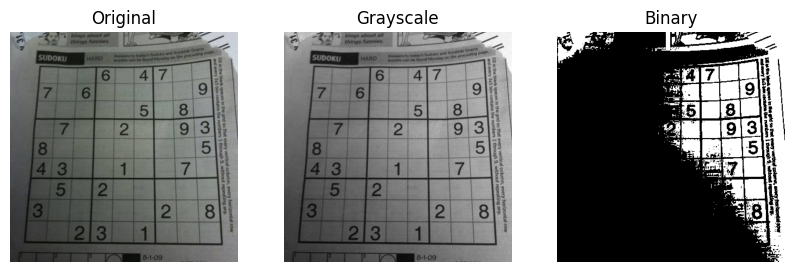

'seuil de 127 : équilibre entre noir et blanc'

In [20]:
# appliquer un seuillage binaire d'un seuil de 127
import cv2
import matplotlib.pyplot as plt
image_sudoku=cv2.imread("sudoku.jpg")
sudoku = cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(sudoku, 127, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sudoku, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(thresh, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.show()

"""seuil de 127 : équilibre entre noir et blanc"""


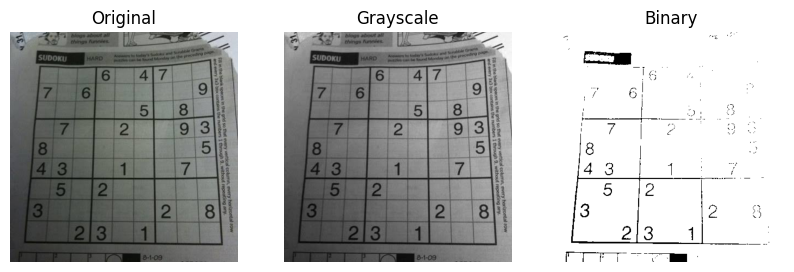

'seuil de 30: presque tout blanc'

In [21]:
# appliquer un seuillage binaire d'un seuil de 30

import cv2
image_sudoku=cv2.imread("sudoku.jpg")
sudoku = cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(sudoku, 30, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sudoku, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(thresh, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.show()
"""seuil de 30: presque tout blanc"""

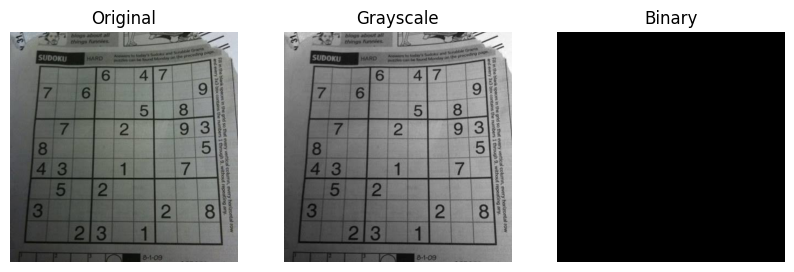

'seuil de 240: image plus sombre'

In [22]:
# appliquer un seuillage binaire d'un seuil de 240
import cv2
image_sudoku=cv2.imread("sudoku.jpg")
sudoku = cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(sudoku, 240, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sudoku, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(thresh, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.show()
"""seuil de 240: image plus sombre"""

Qu'est ce que vous remarquez ?!

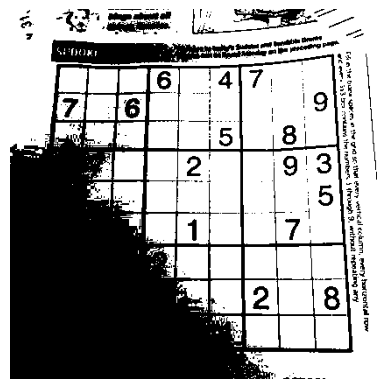

In [23]:
# appliquer "Otsu" seuillage
image_sudoku=cv2.imread("sudoku.jpg")
sudoku = cv2.cvtColor(image_sudoku, cv2.COLOR_BGR2GRAY)
_, t = cv2.threshold(sudoku, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(t, cmap="gray")
plt.axis("off")
plt.show()

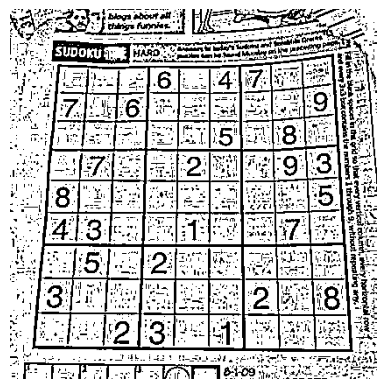

In [24]:
# appliquer "Adaptive threshold"
t=cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
plt.imshow(t, cmap="gray")
plt.axis("off")
plt.show()

# Détection des bords

* Sobel
* Canny

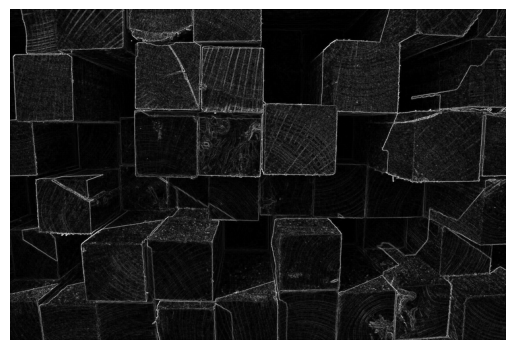

In [43]:
# utiliser la methode sobel pour détecter les bords
# Vous pouvez utiliser d'autres images de votre choix
image_bois=cv2.imread("bois.png")
gray_bois=cv2.cvtColor(image_bois, cv2.COLOR_BGR2GRAY) #sobel fonctionne mieux en gris
sobel_x=cv2.Sobel(gray_bois, cv2.CV_64F,1,0,ksize=3) #détecter les bords horizontaux
sobel_y=cv2.Sobel(gray_bois, cv2.CV_64F,0,1,ksize=3) #détecter les bords verticaux  
sobel_x=cv2.convertScaleAbs(sobel_x) # convertir les valeurs en entier positif
sobel_y=cv2.convertScaleAbs(sobel_y)
sobil_combined=cv2.addWeighted(sobel_x,0.5,sobel_y,0.5,0) #combiner les deux images de bords
plt.imshow(sobil_combined, cmap="gray")
plt.axis("off")
plt.show()


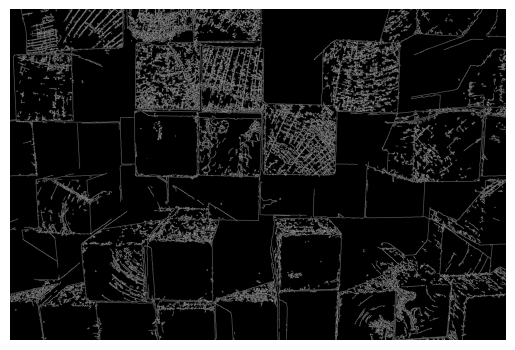

In [47]:
# Canny
t_lower=60
t_upper=150
edges=cv2.Canny(image_bois,t_lower,t_upper)
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()


# Détection des contours

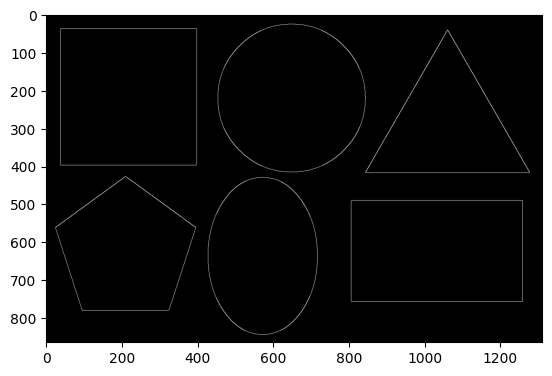

In [51]:
# charger l'image 02
# faites une recherche sur internet pour détecter les contours des objets dans image_02
image_2= cv2.imread("image_02.png")
gray_2=cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)
edges_2=cv2.Canny(gray_2,70,150)
plt.imshow(edges_2, cmap="gray")
plt.show()


#  Compter des objets

In [59]:
# Compter les objets
dilated = cv2.dilate(edges_2, (1, 1), iterations=0)
(cnt,hierarchy) = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rgb=cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)
cv2.drawContours(rgb, cnt, -1, (0, 255, 0), 2)

print("Nombre d'objets détectés:", len(cnt))


Nombre d'objets détectés: 7


# Challenge
Compter le nombre d'objets dans l'image 03 avec le code précédent.
- Qu'est ce que vous remarquez?
- Utiliser l'algorithme Watershed pour detecter et séparer les objets connectés.

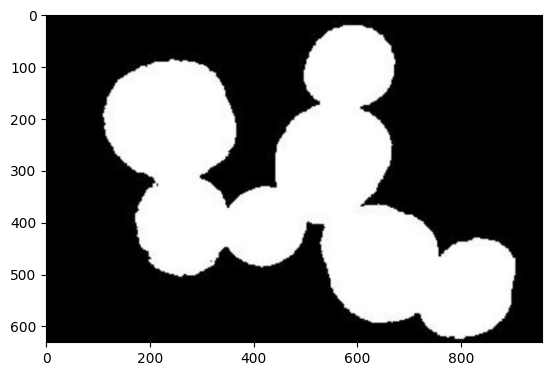

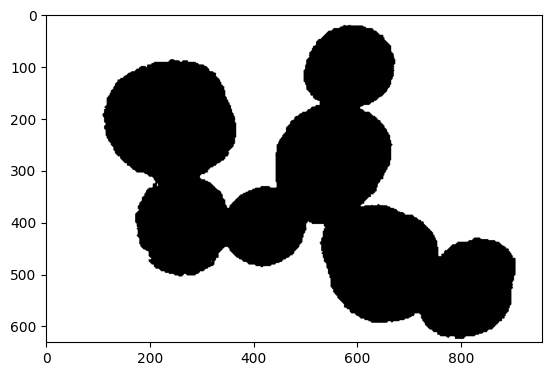

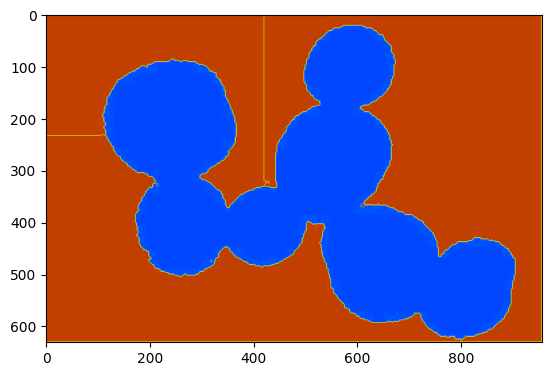

Nombre d'objets détectés: 4


In [85]:
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage import morphology, feature, measure    

image_3=cv2.imread("image_03.jpg")
# Convertir en niveaux de gris
image_3_gray=cv2.cvtColor(image_3, cv2.COLOR_BGR2GRAY)
plt.imshow(image_3_gray, cmap="gray")
plt.show()

#Appliquer un seuillage binaire avec Otsu
_, thresh = cv2.threshold(image_3_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap="gray")
plt.show()

#nettoyege(morphologie)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)


#identification du Zone arriere plan
sure_bg = cv2.dilate(opening, kernel, iterations=3)

#distances transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.6* dist_transform.max(), 255, type=cv2.THRESH_BINARY)
#identification des régions inconnus


#convertir sure_bg en uint8
sure_fg = np.uint8(sure_fg)
#zone inconnu 
unknown = cv2.subtract(sure_bg, sure_fg)

#ajouter 1 pour éviter 0
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(image_3, markers)
image_3[markers == -1] = [255, 0, 0]

#compter les objets 
labels = measure.label(markers)
 # -1 pour exclure le fond

plt.imshow(cv2.cvtColor(image_3, cv2.COLOR_LAB2BGR))
plt.show()
print("Nombre d'objets détectés:", len(np.unique(labels)) - 1)

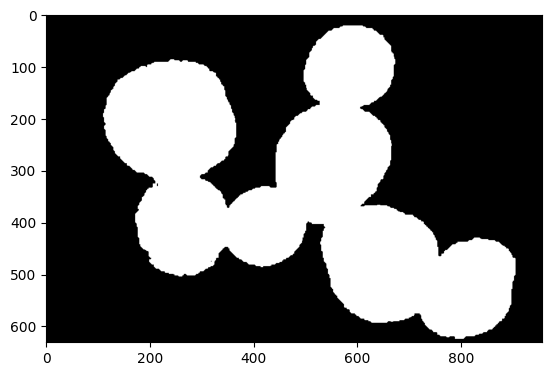

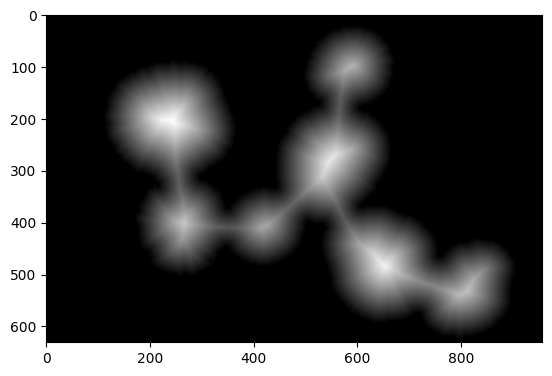

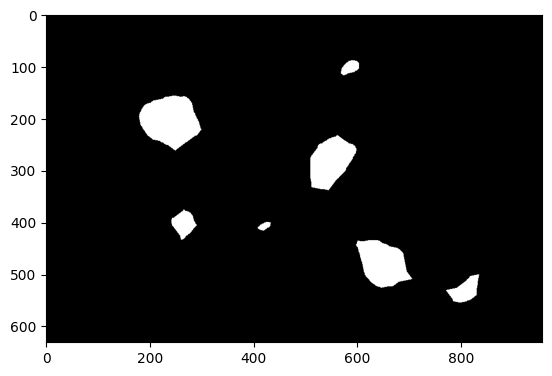

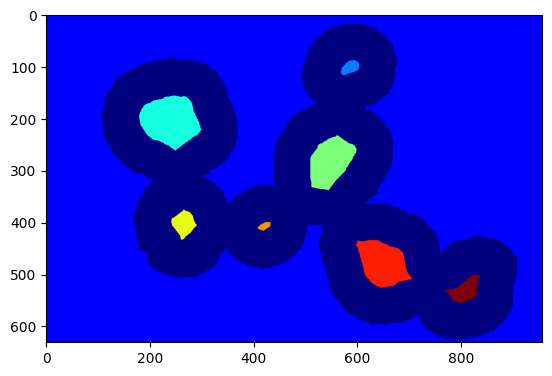

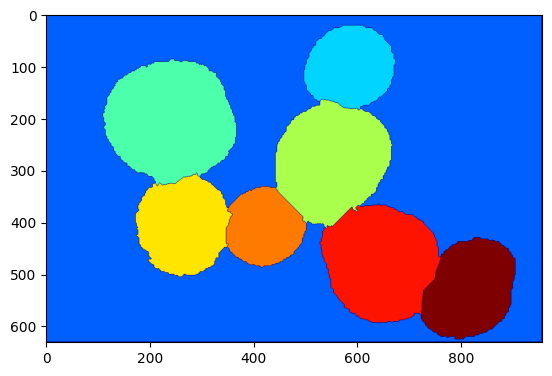

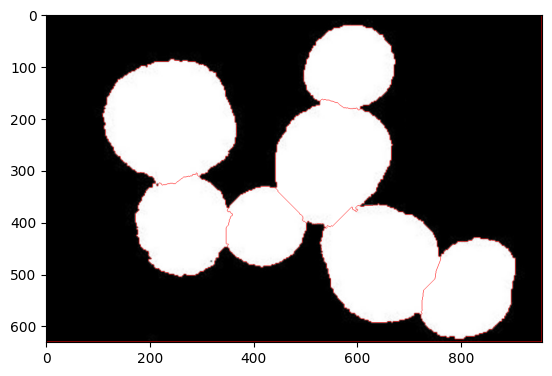

Nombre d'objets détectés: 8


In [87]:
image = cv2.imread("image_03.jpg")
gray = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
 
seuil, img_thresh = cv2.threshold(src=gray, thresh=0, maxval=255, type=(cv2.THRESH_BINARY + cv2.THRESH_OTSU))
 
# Élimination du bruit blanc
kernel = np.ones(shape=(3,3), dtype=np.uint8)
opening = cv2.morphologyEx(img_thresh, kernel=kernel, op=cv2.MORPH_OPEN, iterations=2)
 
# Identification du background
sure_bg = cv2.dilate(opening, kernel=kernel, iterations=3)
 
# Identification du premier plan
dist_transform = cv2.distanceTransform(opening, distanceType=cv2.DIST_L2, maskSize=5)
seuil, premier_plan_sur = cv2.threshold(dist_transform, thresh=(0.6*dist_transform.max()), maxval=255, type=cv2.THRESH_BINARY)
 
# Identification des régions inconues
plt.imshow(opening, cmap='gray')
plt.show()
plt.imshow(dist_transform, cmap='gray')
plt.show()
plt.imshow(premier_plan_sur, cmap='gray')
plt.show()
 
# repérages des régions incertaines
premier_plan_sur = np.uint8(premier_plan_sur)
inconues = cv2.subtract(sure_bg, premier_plan_sur)
 
# Création de marqueurs à partir de premier plan sur
ret, markers = cv2.connectedComponents(premier_plan_sur)
 
# Signalement des marqueurs 
markers = markers+1
 
# Signalement des marqueurs inconnus
markers[inconues==255] = 0
plt.imshow(markers, cmap='jet')
plt.show()
markers = cv2.watershed(image=image, markers=markers)
image[markers == -1] = [255,0,0]
 
plt.imshow(markers, cmap='jet')
plt.show()
plt.imshow(image, cmap='jet')
plt.show()
print("Nombre d'objets détectés:", len(np.unique(markers)) - 1)

Bravo !